<a href="https://colab.research.google.com/github/whitebearhands/lineart-lora/blob/main/lineart_lora_a100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q diffusers transformers accelerate safetensors
!pip install -q peft bitsandbytes xformers
!pip install -q Pillow datasets huggingface_hub

print("\n✅ 설치 완료!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 48.1 MB/s eta 0:00:00

✅ 설치 완료!


In [1]:
!nvidia-smi

Wed Apr  8 04:25:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print("\n✅ 준비 완료! 다음 단계로 진행하세요.")
else:
    print("\n❌ GPU가 감지되지 않습니다. 런타임 → 런타임 유형 변경 → T4 GPU 설정하세요.")

PyTorch: 2.10.0+cu128
CUDA 사용 가능: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 39.5 GB

✅ 준비 완료! 다음 단계로 진행하세요.


In [4]:
from diffusers import StableDiffusionPipeline
import torch

MODEL_NAME = "runwayml/stable-diffusion-v1-5"

# 모델 다운로드 (캐시됨 - 두 번째부터는 빠름)
print("모델 다운로드 중... (첫 실행 시 약 5분 소요)")
pipeline = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    safety_checker=None,
)
print("\n✅ 베이스 모델 다운로드 완료!")

# 메모리 절약을 위해 파이프라인 삭제 (학습 시 다시 로드)
del pipeline
torch.cuda.empty_cache()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


모델 다운로드 중... (첫 실행 시 약 5분 소요)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul


✅ 베이스 모델 다운로드 완료!


In [7]:
from google.colab import drive
drive.mount('/content/drive' , force_remount=True)

!unzip /content/drive/MyDrive/dataset.zip -d /content/train_data

Mounted at /content/drive
Archive:  /content/drive/MyDrive/dataset.zip
  inflating: /content/train_data/address-amico-1081.png  
  inflating: /content/train_data/address-bro-2342.png  
  inflating: /content/train_data/address-cuate-5767.png  
  inflating: /content/train_data/address-pana-1219.png  
  inflating: /content/train_data/address-rafiki-911.png  
  inflating: /content/train_data/add-user-bro-1304.png  
  inflating: /content/train_data/add-user-pana-1402.png  
  inflating: /content/train_data/adopt-a-pet-amico-2944.png  
  inflating: /content/train_data/adopt-a-pet-bro-2885.png  
  inflating: /content/train_data/adopt-a-pet-cuate-7315.png  
  inflating: /content/train_data/adopt-a-pet-pana-2934.png  
  inflating: /content/train_data/adopt-a-pet-rafiki-2986.png  
  inflating: /content/train_data/advent-calendar-amico-4770.png  
  inflating: /content/train_data/advent-calendar-bro-5118.png  
  inflating: /content/train_data/advent-calendar-cuate-4750.png  
  inflating: /content/t

In [9]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import os
from PIL import Image

# ===== 트리거 워드 설정 =====
# 이 단어를 프롬프트에 넣으면 학습된 스타일이 적용됩니다
TRIGGER_WORD = "lineart_style"  # 원하는 단어로 변경 가능
# ============================

print("BLIP 캡셔닝 모델 로딩 중...")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base",
    torch_dtype=torch.float16
).to("cuda")

print("캡션 생성 중...\n")

for fname in sorted(os.listdir(TRAIN_DIR)): # Changed PROCESSED_DIR to TRAIN_DIR
    if not fname.endswith('.png'):
        continue

    img_path = os.path.join(TRAIN_DIR, fname) # Changed PROCESSED_DIR to TRAIN_DIR
    img = Image.open(img_path).convert("RGB")

    # BLIP으로 캡션 생성
    inputs = blip_processor(img, return_tensors="pt").to("cuda", torch.float16)
    output = blip_model.generate(**inputs, max_new_tokens=50)
    caption = blip_processor.decode(output[0], skip_special_tokens=True)

    # 트리거 워드를 앞에 추가
    full_caption = f"{TRIGGER_WORD}, {caption}"

    # 같은 이름의 .txt 파일로 저장
    txt_path = img_path.replace('.png', '.txt')
    with open(txt_path, 'w') as f:
        f.write(full_caption)

    print(f"  {fname} → {full_caption}")

# BLIP 모델 메모리 해제
del blip_model, blip_processor
torch.cuda.empty_cache()

print(f"\n✅ 캡셔닝 완료! 트리거 워드: '{TRIGGER_WORD}'")
print("💡 생성 시 프롬프트에 이 단어를 넣으면 학습된 스타일이 적용됩니다.")

BLIP 캡셔닝 모델 로딩 중...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

캡션 생성 중...

  2021-pana-4761.png → lineart_style, a woman in a black dress holding a pink balloon and a star
  4th-of-july-amico-10670.png → lineart_style, people celebrating the statue of liberty
  4th-of-july-bro-10828.png → lineart_style, independence day clipart clipart
  4th-of-july-cuate-10830.png → lineart_style, two people holding american flags and balloons
  4th-of-july-pana-10680.png → lineart_style, three people in patriotic outfits holding balloons
  4th-of-july-rafiki-11793.png → lineart_style, a man in a suit and hat holding an american flag
  50th-birthday-amico-8770.png → lineart_style, a woman is standing next to a cake
  50th-birthday-bro-8741.png → lineart_style, a birthday cake with balloons and cons
  50th-birthday-pana-8612.png → lineart_style, a woman celebrating her 30th birthday with balloons and a cake
  50th-birthday-rafiki-8930.png → lineart_style, a man is putting a balloon into a box
  80s-bro-2172.png → lineart_style, a woman is walking past a cassette
 

In [10]:
MAX_TRAIN_STEPS = 5000
TRAIN_BATCH_SIZE = 4        # A100 VRAM 40GB, 넉넉함
GRADIENT_ACCUMULATION = 2
LEARNING_RATE = 1e-4
LORA_RANK = 64
LORA_ALPHA = 32
SAVE_EVERY_N_STEPS = 500
# =====================

OUTPUT_DIR = "/content/lora_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"학습 설정:")
print(f"  LoRA Rank: {LORA_RANK}, Alpha: {LORA_ALPHA}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Steps: {MAX_TRAIN_STEPS}")
print(f"  실질 배치: {TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION}")
print(f"  출력: {OUTPUT_DIR}")

학습 설정:
  LoRA Rank: 64, Alpha: 32
  Learning Rate: 0.0001
  Steps: 5000
  실질 배치: 8
  출력: /content/lora_output


In [11]:
!wget -q https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py -O /content/train_lora.py
print("✅ 학습 스크립트 준비 완료")

✅ 학습 스크립트 준비 완료


In [12]:
import json

DATASET_DIR = "/content/hf_dataset"
os.makedirs(os.path.join(DATASET_DIR, "train"), exist_ok=True)

metadata = []
for fname in sorted(os.listdir(TRAIN_DIR)):
    if not fname.endswith('.png'):
        continue

    txt_file = fname.replace('.png', '.txt')
    txt_path = os.path.join(TRAIN_DIR, txt_file)

    if os.path.exists(txt_path):
        with open(txt_path) as f:
            caption = f.read().strip()
    else:
        caption = TRIGGER_WORD

    # 이미지 복사
    import shutil
    shutil.copy2(
        os.path.join(TRAIN_DIR, fname),
        os.path.join(DATASET_DIR, "train", fname)
    )

    metadata.append({"file_name": fname, "text": caption})

# metadata.jsonl 생성
with open(os.path.join(DATASET_DIR, "train", "metadata.jsonl"), 'w') as f:
    for item in metadata:
        f.write(json.dumps(item) + '\n')

print(f"✅ 데이터셋 준비 완료! ({len(metadata)}장)")

✅ 데이터셋 준비 완료! (2964장)


In [17]:
!accelerate launch /content/train_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/content/hf_dataset/train" \
  --output_dir="{OUTPUT_DIR}" \
  --resolution={RESOLUTION} \
  --train_batch_size={TRAIN_BATCH_SIZE} \
  --gradient_accumulation_steps={GRADIENT_ACCUMULATION} \
  --learning_rate={LEARNING_RATE} \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=100 \
  --max_train_steps={MAX_TRAIN_STEPS} \
  --checkpointing_steps={SAVE_EVERY_N_STEPS} \
  --rank={LORA_RANK} \
  --seed=42 \
  --mixed_precision="fp16" \
  --enable_xformers_memory_efficient_attention \
  --caption_column="text"

print("\n" + "="*50)
print("🎉 LoRA 학습 완료!")
print(f"모델 저장 위치: {OUTPUT_DIR}")
print("="*50)

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
INFO:__main__:[RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ig

In [18]:
from diffusers import StableDiffusionPipeline
import torch

# 베이스 모델 + LoRA 로드
print("모델 로딩 중...")
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None,
).to("cuda")

# 학습된 LoRA 적용
pipe.load_lora_weights(OUTPUT_DIR)
print("✅ LoRA 로드 완료!")

모델 로딩 중...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

✅ LoRA 로드 완료!


생성 중 (1/4): lineart_style, a person sitting at a desk working on a compu...


  0%|          | 0/30 [00:00<?, ?it/s]

생성 중 (2/4): lineart_style, a doctor talking to a patient in a hospital, ...


  0%|          | 0/30 [00:00<?, ?it/s]

생성 중 (3/4): lineart_style, a chef cooking in a kitchen, black and white ...


  0%|          | 0/30 [00:00<?, ?it/s]

생성 중 (4/4): lineart_style, a teacher standing in front of a classroom, s...


  0%|          | 0/30 [00:00<?, ?it/s]

/tmp/ipykernel_1867/2261476255.py:43: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1867/2261476255.py:43: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1867/2261476255.py:43: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1867/2261476255.py:43: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1867/2261476255.py:43: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1867/2261476255.py:43: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1867/2261476255.py:43: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.ti

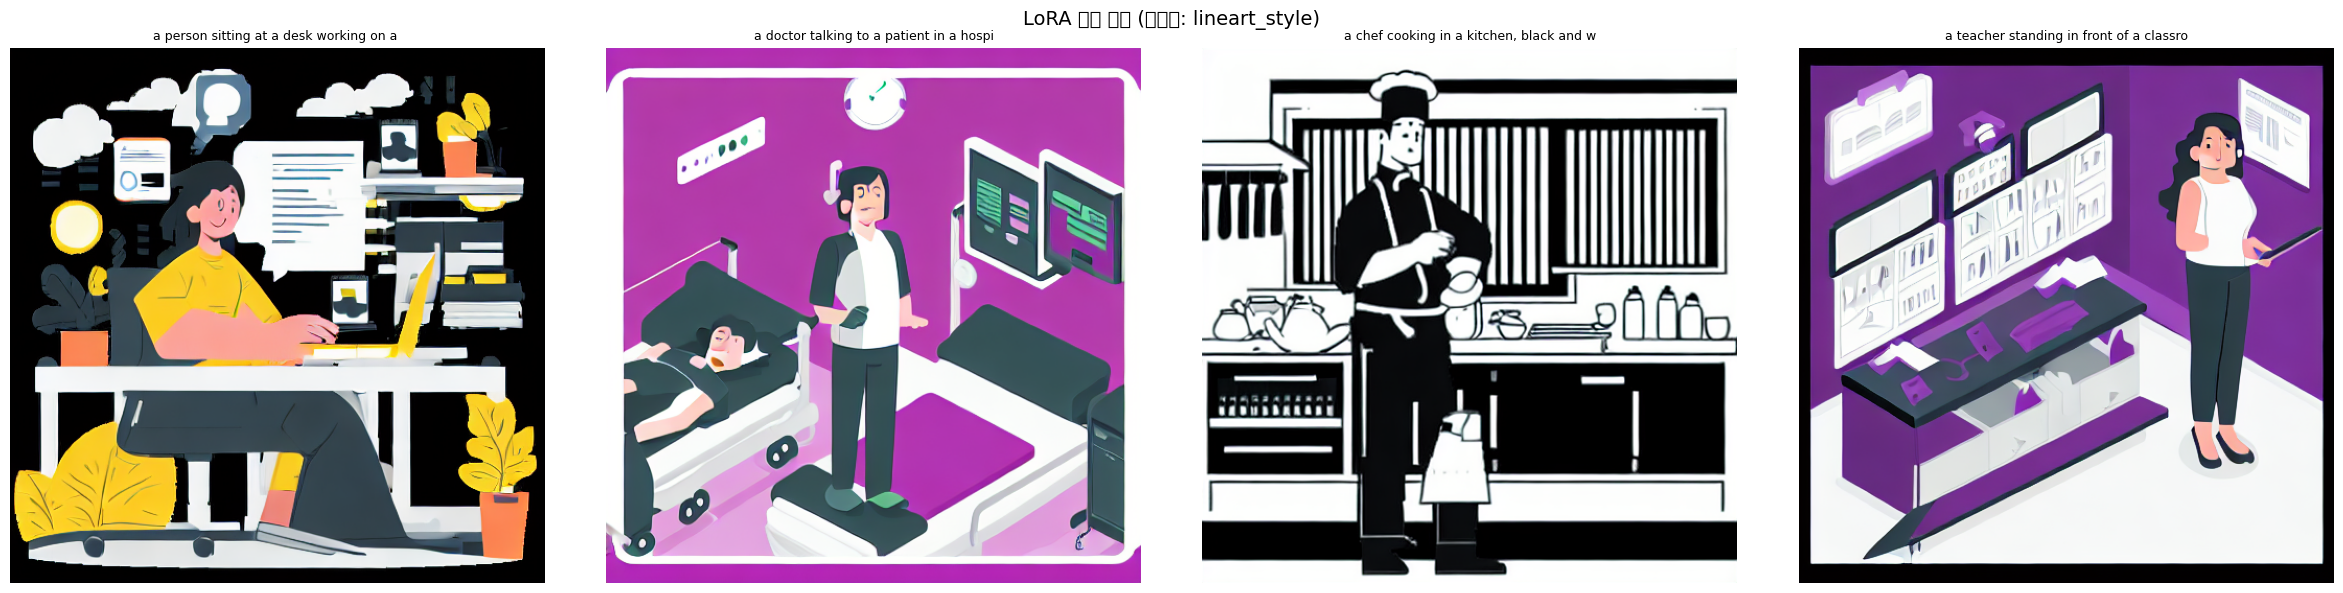


✅ 생성 완료! /content/result_*.png 로 저장됨


In [19]:
# 이미지 생성 테스트

# ===== 프롬프트 수정 영역 =====
test_prompts = [
    f"{TRIGGER_WORD}, a person sitting at a desk working on a computer, clean lines, white background",
    f"{TRIGGER_WORD}, a doctor talking to a patient in a hospital, minimal illustration",
    f"{TRIGGER_WORD}, a chef cooking in a kitchen, black and white line drawing",
    f"{TRIGGER_WORD}, a teacher standing in front of a classroom, simple outline",
]

NEGATIVE_PROMPT = "blurry, low quality, color, watercolor, photorealistic, 3d render"
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 7.5
# ==============================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(test_prompts), figsize=(6 * len(test_prompts), 6))
if len(test_prompts) == 1:
    axes = [axes]

for i, (ax, prompt) in enumerate(zip(axes, test_prompts)):
    print(f"생성 중 ({i+1}/{len(test_prompts)}): {prompt[:60]}...")

    image = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE_PROMPT,
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        generator=torch.Generator("cuda").manual_seed(42 + i),
    ).images[0]

    ax.imshow(image)
    # 프롬프트에서 트리거워드 제외하고 표시
    short_prompt = prompt.replace(f"{TRIGGER_WORD}, ", "")[:40]
    ax.set_title(short_prompt, fontsize=9)
    ax.axis('off')

    # 개별 저장
    image.save(f"/content/result_{i:02d}.png")

plt.suptitle(f"LoRA 생성 결과 (트리거: {TRIGGER_WORD})", fontsize=14)
plt.tight_layout()
plt.show()

print("\n✅ 생성 완료! /content/result_*.png 로 저장됨")

In [21]:
from huggingface_hub import HfApi, login

# 허깅페이스 토큰 입력 (https://huggingface.co/settings/tokens 에서 발급)
login()

api = HfApi()

# 리포지토리 생성 + 업로드
REPO_ID = "whitebearhands/lineart-lora"  # 본인 아이디/모델명으로 수정

api.create_repo(REPO_ID, exist_ok=True)

# LoRA 파일 업로드
api.upload_folder(
    folder_path="/content/lora_output",
    repo_id=REPO_ID,
    commit_message="Upload lineart LoRA"
)

print(f"✅ 업로드 완료! https://huggingface.co/{REPO_ID}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...checkpoint-3000/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ...-1000/random_states_0.pkl:   1%|1         |   161B / 14.8kB            

  ..._lora_weights.safetensors:   1%|1         |  557kB / 51.1MB            

...

  ...checkpoint-2000/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ...checkpoint-3500/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ...kpoint-1000/optimizer.bin:   1%|          |  581kB /  102MB            

  ...kpoint-1500/optimizer.bin:   1%|          |  570kB /  102MB            

✅ 업로드 완료! https://huggingface.co/whitebearhands/lineart-lora
